# MIDI Player Test

In [131]:
from midi2audio import FluidSynth

In [132]:
midi_file = '../../data/midi_files/Yaman/Slow Swar Vistar/Slow Swar Vistar - 1.0.mid'

In [133]:
# using the default sound font in 44100 Hz sample rate
fs = FluidSynth('/usr/share/sounds/sf2/')
fs.midi_to_audio(midi_file, 'output.wav')

fluidsynth: error: fluid_is_soundfont(): fopen() failed: 'File is not regular, refusing to open it.'
Parameter '/usr/share/sounds/sf2/' not a SoundFont or MIDI file or error occurred identifying it.


FluidSynth runtime version 2.2.5
Copyright (C) 2000-2022 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.

Rendering audio to file 'output.wav'..


In [134]:
from IPython.display import Audio, display

# Replace 'my_audio_file.wav' with the path to your WAV file
audio_file_path = 'output.wav' 

# Create and display the audio player widget
display(Audio(audio_file_path))

# MidiTok PerTok

## Initialize PerTok Tokenizer

In [135]:
from miditok import PerTok, TokenizerConfig

In [162]:
TOKENIZER_PARAMS = {
    "pitch_range": (21, 109),
    "beat_res": {(0, 4): 4},
    "special_tokens": ["PAD", "BOS", "EOS", "MASK"],
    "use_chords": False,
    "use_rests": False,
    "use_tempos": False,
    "use_time_signatures": True,
    "use_programs": False,
    "use_microtiming": True,
    "ticks_per_quarter": 96,
    "max_microtiming_shift": 0.125,
    "num_microtiming_bins": 24,
    "use_position_toks": True
}

In [163]:
tokenizer = PerTok(TokenizerConfig(**TOKENIZER_PARAMS))

In [164]:
tokenizer.durations

[(0, 24, 96),
 (0, 48, 96),
 (0, 72, 96),
 (1, 0, 96),
 (1, 24, 96),
 (1, 48, 96),
 (1, 72, 96),
 (2, 0, 96),
 (2, 24, 96),
 (2, 48, 96),
 (2, 72, 96),
 (3, 0, 96),
 (3, 24, 96),
 (3, 48, 96),
 (3, 72, 96)]

In [165]:
tokenizer.position_locations

[0, 24, 48, 72, 96, 120, 144, 168, 192, 216, 240, 264, 288, 312, 336, 360]

In [166]:
tokenizer.vocab

{'PAD_None': 0,
 'BOS_None': 1,
 'EOS_None': 2,
 'MASK_None': 3,
 'Bar_None': 4,
 'Pitch_21': 5,
 'Pitch_22': 6,
 'Pitch_23': 7,
 'Pitch_24': 8,
 'Pitch_25': 9,
 'Pitch_26': 10,
 'Pitch_27': 11,
 'Pitch_28': 12,
 'Pitch_29': 13,
 'Pitch_30': 14,
 'Pitch_31': 15,
 'Pitch_32': 16,
 'Pitch_33': 17,
 'Pitch_34': 18,
 'Pitch_35': 19,
 'Pitch_36': 20,
 'Pitch_37': 21,
 'Pitch_38': 22,
 'Pitch_39': 23,
 'Pitch_40': 24,
 'Pitch_41': 25,
 'Pitch_42': 26,
 'Pitch_43': 27,
 'Pitch_44': 28,
 'Pitch_45': 29,
 'Pitch_46': 30,
 'Pitch_47': 31,
 'Pitch_48': 32,
 'Pitch_49': 33,
 'Pitch_50': 34,
 'Pitch_51': 35,
 'Pitch_52': 36,
 'Pitch_53': 37,
 'Pitch_54': 38,
 'Pitch_55': 39,
 'Pitch_56': 40,
 'Pitch_57': 41,
 'Pitch_58': 42,
 'Pitch_59': 43,
 'Pitch_60': 44,
 'Pitch_61': 45,
 'Pitch_62': 46,
 'Pitch_63': 47,
 'Pitch_64': 48,
 'Pitch_65': 49,
 'Pitch_66': 50,
 'Pitch_67': 51,
 'Pitch_68': 52,
 'Pitch_69': 53,
 'Pitch_70': 54,
 'Pitch_71': 55,
 'Pitch_72': 56,
 'Pitch_73': 57,
 'Pitch_74': 58,
 'Pitc

## Re-Construct a MIDI File

In [141]:
import muspy

from pprint import pprint

In [142]:
midi_file = '../../data/midi_files/Yaman/Aao Balma/Aao Balma  - Sthaayi 1.1.mid'

### Visualize Input

[<Axes: xlabel='time (beat)', ylabel='\n\npitch'>]

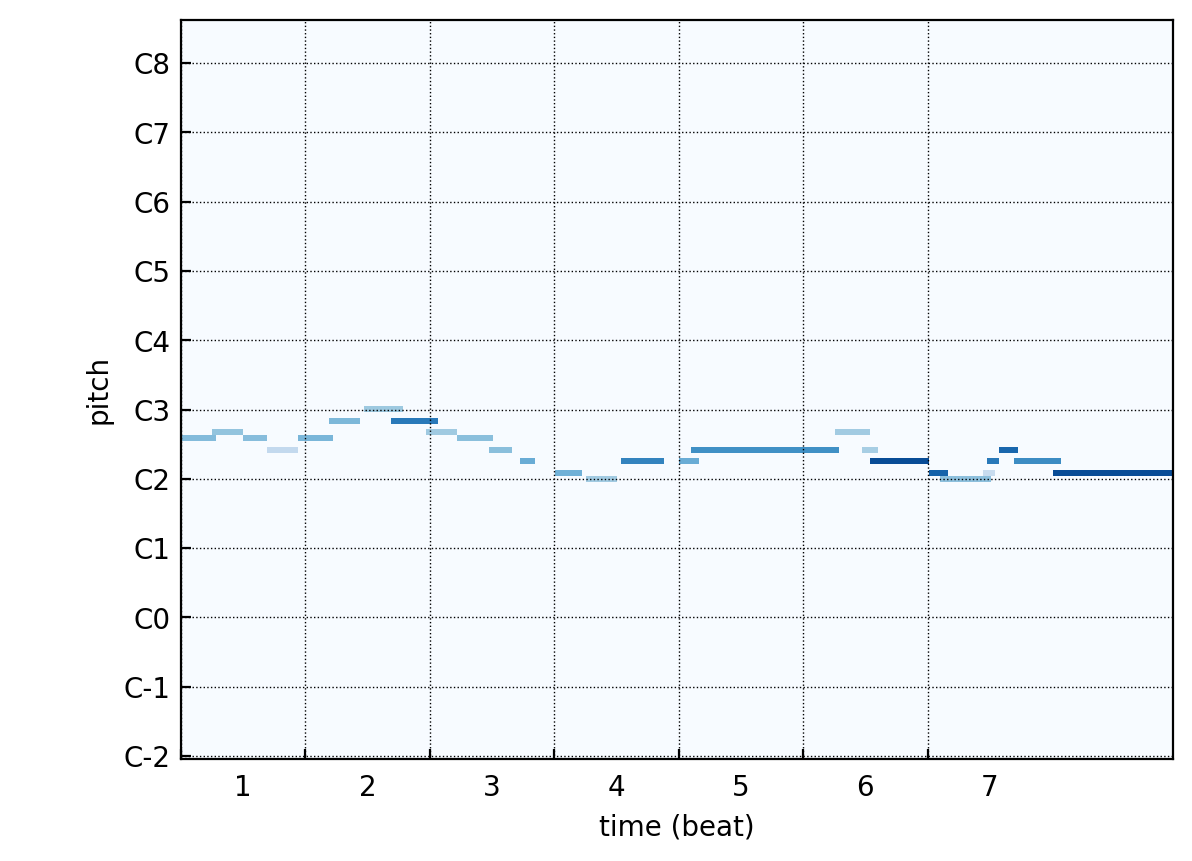

In [143]:
muspy.show_pianoroll(muspy.read_midi(midi_file))

### Tokenize Input

In [144]:
tokens = tokenizer(midi_file)

pprint(tokens)

[TokSequence(tokens=['TimeSig_4/4',
                     'Pitch_55',
                     'MicroTiming_0',
                     'Velocity_55',
                     'Duration_0.24.96',
                     'Position_24',
                     'Pitch_56',
                     'MicroTiming_0',
                     'Velocity_51',
                     'Duration_0.24.96',
                     'Position_48',
                     'Pitch_55',
                     'MicroTiming_0',
                     'Velocity_55',
                     'Duration_0.24.96',
                     'Position_72',
                     'Pitch_53',
                     'MicroTiming_-6',
                     'Velocity_35',
                     'Duration_0.24.96',
                     'Position_96',
                     'Pitch_55',
                     'MicroTiming_-6',
                     'Velocity_59',
                     'Duration_0.24.96',
                     'Position_120',
                     'Pitch_58',
        

### Re-Construct MIDI from Tokenized Sequence

In [145]:
output_midi_file = 'decoded_midi.mid'

In [146]:
generated_midi = tokenizer(tokens)
generated_midi.dump_midi(output_midi_file)

### Visualize Output

[<Axes: xlabel='time (beat)', ylabel='\n\npitch'>]

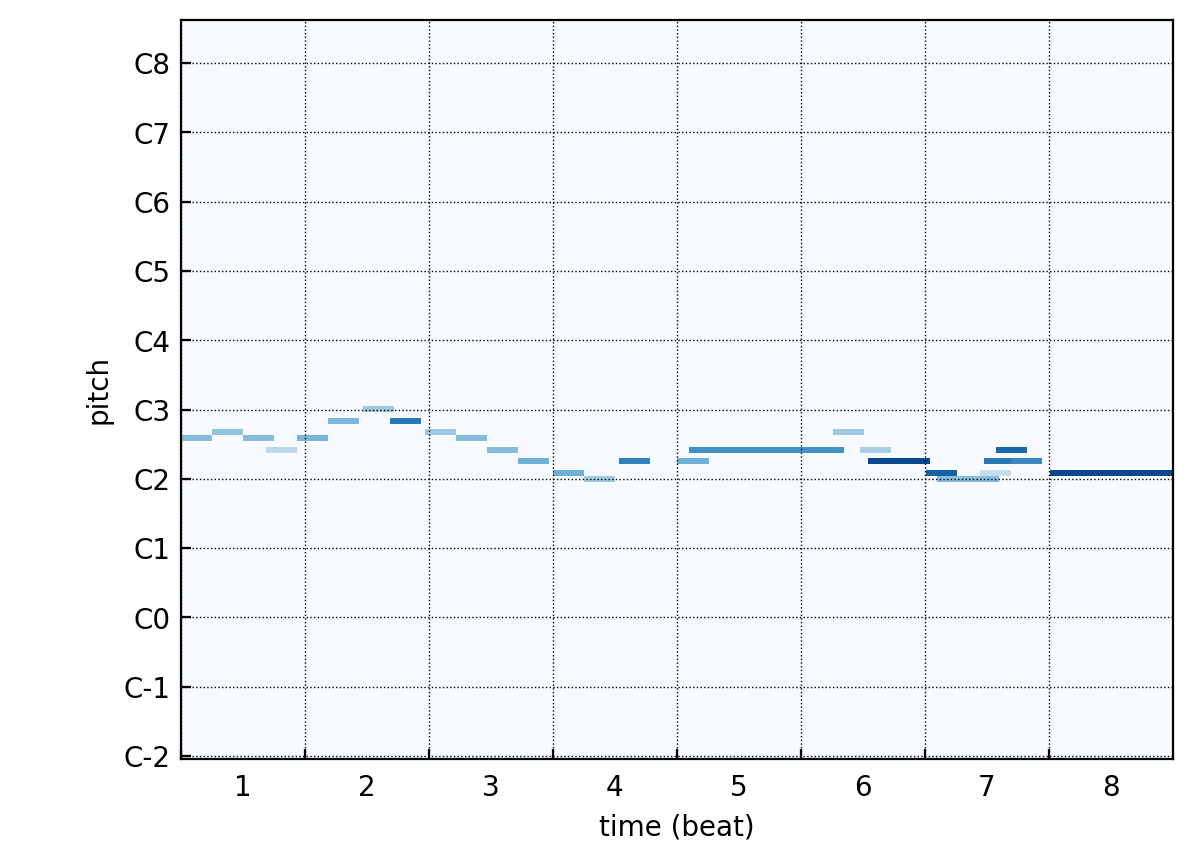

In [147]:
muspy.show_pianoroll(muspy.read_midi(output_midi_file))

# Analysis of All Melodies

In [93]:
import os
import muspy

In [107]:
muspy_objs = {}

for i, os_walk_tuple in enumerate(os.walk('../../data/midi_files/')):
    files_list = os_walk_tuple[2]
    
    for filename in files_list:
        directory = os_walk_tuple[0]

        if filename[-3:] == 'mid':
            muspy_objs[filename] = muspy.read_midi(os.path.join(directory, filename))

## Remove Melodies with Notes that are longer than a bar

In [151]:
melodies_to_delete = []

for melody_name, melody in muspy_objs.items():
    melody_notes = muspy.to_note_representation(melody)
    if [note[2] for note in melody_notes if note[2] > 96*4]:
        melodies_to_delete.append(melody_name)

for melody_name in melodies_to_delete:
    del muspy_objs[melody_name]

## Histogram of Note Durations?

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

In [110]:
note_durations = [note[2] for melody in muspy_objs.values() for note in muspy.to_note_representation(melody)]

[Text(0.5, 0, 'Ticks (96/quarter_note)')]

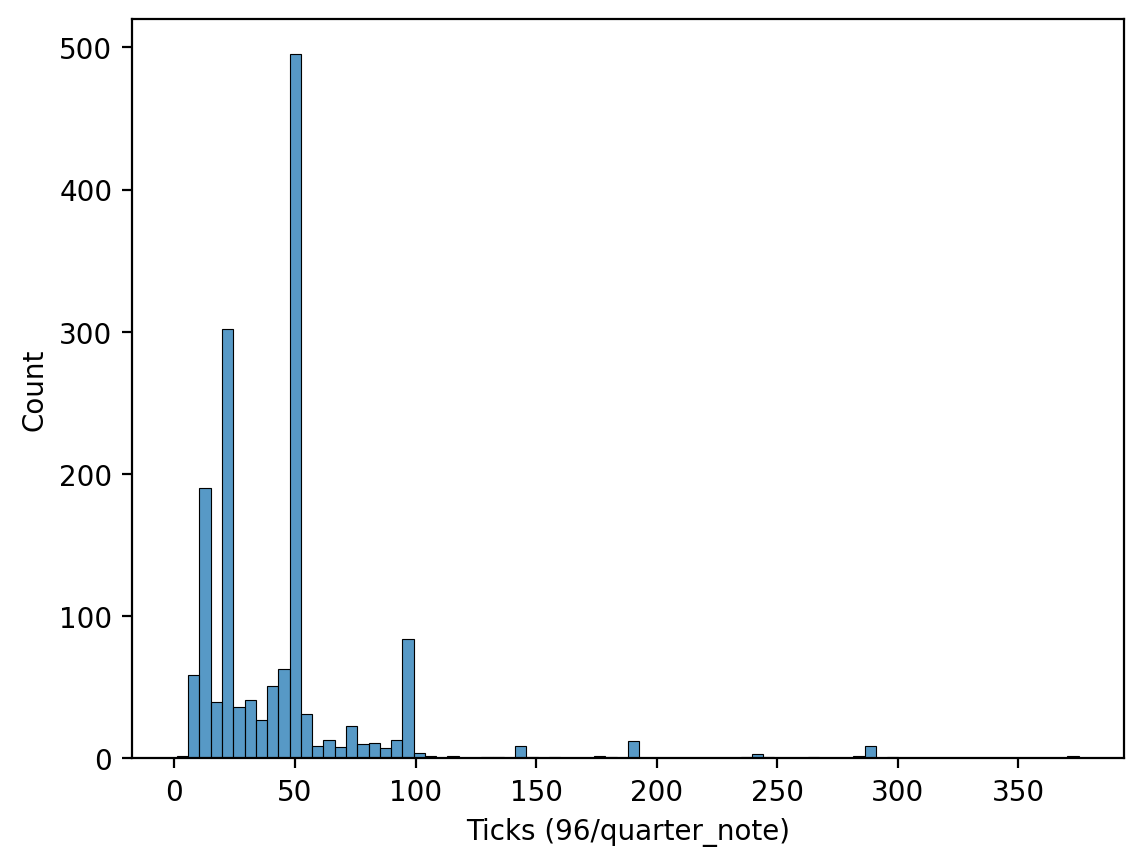

In [149]:
ax = sns.histplot(data=[duration for duration in note_durations if duration < 96*4])
ax.set(xlabel='Ticks (96/quarter_note)')